# Basic utils for Investing based on Indicators

## Imports

In [2]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import random
import plotly.express as px

# Attribution d'une graine.
random.seed(1)

torch.manual_seed(1)

%reload_ext autoreload
%autoreload 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data reading and processing

In [33]:
pair = 'SOLUSDT'
timeframe = '5m'
type_data = 'Futures'

# Importation des données


data = pd.read_csv(f'../data/binance/{pair}_{timeframe}_{type_data}.csv', parse_dates=[0], index_col=0)
data

,Open,High,Low,Close,Volume,Qav,Trades,Taker_base_vol,Taker_quote_vol
Date,,,,,,,,,
2020-09-14 09:00:00,3.2002,4.9100,3.2002,3.3045,42698,1.426940e+05,640,15267,5.195271e+04
2020-09-14 09:05:00,3.3045,3.3974,3.2844,3.3497,51149,1.712361e+05,1152,28120,9.440854e+04
2020-09-14 09:10:00,3.3486,3.3576,3.3151,3.3393,23974,7.976511e+04,675,6843,2.276923e+04
2020-09-14 09:15:00,3.3443,3.4189,3.3353,3.3834,65640,2.223665e+05,1231,24917,8.447305e+04
2020-09-14 09:20:00,3.3855,3.4149,3.3709,3.3787,55165,1.865342e+05,825,11150,3.776340e+04
...,...,...,...,...,...,...,...,...,...
2024-09-04 19:35:00,133.0160,133.2070,132.5270,132.9030,173991,2.312146e+07,13635,64643,8.591545e+06
2024-09-04 19:40:00,132.9040,133.3170,132.7000,132.7360,72642,9.664593e+06,6799,36578,4.867733e+06
2024-09-04 19:45:00,132.7360,133.1360,132.7330,133.0310,43489,5.781083e+06,4668,24068,3.199412e+06


0.001651115573386692


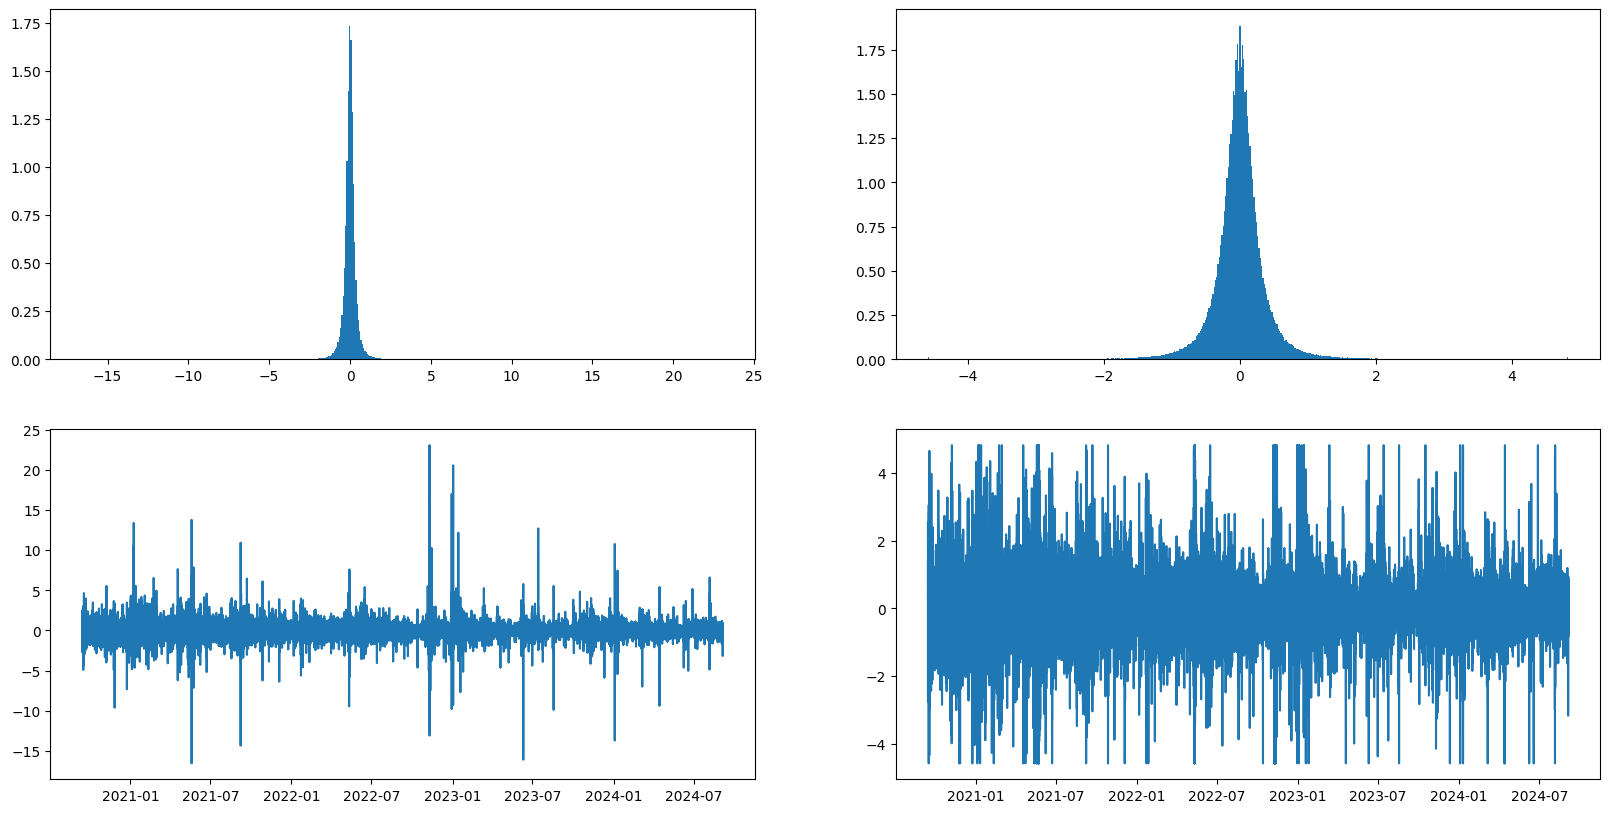

In [34]:
data.loc[:, '%R'] = data['Close'].pct_change()*100

df = data[['%R']].copy()

quatiles_threshold = 0.0002

plt.figure(figsize=(20, 10))

plt.subplot(2, 2, 1)    
plt.hist(df['%R'] , bins=500, density=True)

plt.subplot(2, 2, 3)
plt.plot(df['%R'])

df['%R'] = df['%R'].clip(lower=df['%R'].quantile(quatiles_threshold), upper=df['%R'].quantile(1-quatiles_threshold))

print(df['%R'].mean())

# df['%R'] = df['%R'] - df['%R'].mean()

plt.subplot(2, 2, 2)
plt.hist(df['%R'], bins=500, density=True)

plt.subplot(2, 2, 4)
plt.plot(df['%R'])

plt.show()

In [35]:
import ta


df.dropna(inplace=True)


In [36]:
df.describe()

,%R
count,418019.000000
mean,0.001651
std,0.415585
min,-4.582954
25%,-0.165888
50%,0.000000
75%,0.166059
max,4.829074


In [37]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

train_data, test_data = df[:int(len(data)*0.8)], df[int(len(data)*0.8):]

train_data = train_data.to_numpy()

test_data = test_data.to_numpy()

start_index = 0

train_target = train_data[:, :1]

test_target = test_data[:, :1]

for k in range(0, 2):
    train_target = train_target - train_target.mean()
    test_target = test_target - test_target.mean()
    
    print(f'k = {k}: train_target mean = {train_target.mean()}, test_target mean = {test_target.mean()}')

scaler = StandardScaler()


train_data = scaler.fit_transform(train_data[:, start_index:]) 
test_data = scaler.transform(test_data[:, start_index:])

k = 0: train_target mean = 7.054093951017693e-18, test_target mean = 2.5497030097966587e-18
k = 1: train_target mean = 4.334443271107257e-18, test_target mean = 2.5284554847150198e-18


In [14]:
def run_epoch(model, dataloader, optimizer, criterion, update_description=1):
    
    model.train()
    
    epoch_loss = 0

    batchs_number = len(dataloader)

    batchs = tqdm(enumerate(dataloader), unit='batch', total=batchs_number)
    for idx, (src, tgt_mask, tgt) in batchs:

        src = src.to(device)

        tgt = tgt.to(device)

        optimizer.zero_grad()

        out = model(src, tgt_mask.to(device))

        loss = criterion(out.contiguous(), tgt.contiguous())
        
        loss.backward()
        optimizer.step()
        epoch_loss += (loss.detach().item())

        if (idx + update_description) % round(batchs_number/update_description) == 0:
            batchs.set_description('MSE {:.3E} '.format(
                epoch_loss/(idx+1)))

    return epoch_loss/batchs_number

In [15]:
def shift_sum(x):
    out = np.zeros((x.shape[0] + x.shape[1]-1))
    
    for k in range(x.shape[0]):
        out[k:k+x.shape[1]] += x[k]
        
    return out

In [16]:
torch2numpy = lambda x: x.cpu().detach().numpy()

def eval_epoch(model, dataloader, points=0):

    prediction = []
    targets = []
    returns = []
    
    with torch.no_grad():
        for idx, (src, tgt_mask, tgt) in enumerate(dataloader):
            pred = model(src.to(device), tgt_mask.to(device))
            prediction.append(torch2numpy(pred[...,0]))
            targets.append(torch2numpy(tgt[...,0]))

    prediction = np.concatenate(prediction, axis=0)
    targets = np.concatenate(targets, axis=0)
    
    # prediction = shift_sum(prediction)/prediction.shape[1]
    # targets = shift_sum(targets)/targets.shape[1]
    
    returns = prediction * targets
    
    norm = np.abs(np.diff(prediction, axis=0)).mean()
    normed_returns = returns/norm
    
    portfolio = np.cumsum(normed_returns)
    

    if points > 0:
        
        plt.figure(figsize=(14, 7))
        plt.subplot(2, 1, 1)
        plt.plot(targets[-points:], label='True')
        plt.plot(prediction[-points:], label='Prediction')
        plt.legend()
        plt.subplot(2, 1, 2)
        plt.plot(returns[-points:], label='Returns')
        plt.legend()
        plt.figure(figsize=(14, 7))
        plt.plot(portfolio, label='Portfolio')
        plt.show()

    return  normed_returns.mean(), norm, returns.mean()

In [17]:
class NN(nn.Module):
    def __init__(self, config):
        super(NN, self).__init__()
        self.input_size = config['input_size']
        self.pred_len = config['pred_len']
        self.hidden_size = config['hidden_size']
        
        self.linear1 = nn.Linear(self.input_size, self.hidden_size)
        self.linear2 = nn.Linear(self.hidden_size, self.hidden_size)
        self.linear3 = nn.Linear(self.hidden_size, self.pred_len)
        self.activation = nn.ReLU() #nn.Tanh()
        self.tanh = nn.Tanh()
        
        
    def forward(self, x, tgt_mask):
        
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        x = self.activation(x)
        x = self.linear3(x)

        return self.tanh(x)

In [18]:
config = {
    # data
 'seq_len': 29,
 'pred_len': 1,
 'batch_size': train_data.shape[0]//1,
 'shuffle': False,
 'output_size': train_data.shape[1],
 'offset': 0,
 
    # model

 'model': NN,
 'input_size': train_data.shape[1],
 
 'hidden_size': 64,
 'num_layers': 2,
 'dropout': 0.0,
 'bidirectional': False,
 
 # Training
 
  'num_epochs': 10,
 'lr': 1e-1,
 'max_grad_norm': 0.1,
 'gamma': 0.2,
 'patience': 10,
 'cd': 0,
 }

class AttrDict(dict):
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

config = AttrDict(config)

In [19]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, data, target, seq_len, pred_len, offset):
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.offset = offset
        
        self.target = target
        
        
        self.data = data[:-(offset+1)].astype(np.float32)
        
        self.target = target[1+offset:].astype(np.float32)
        
        
    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len - self.offset
    
    def __getitem__(self, idx):
        return self.data[idx],torch.zeros(1), self.target[idx]

In [20]:

from torch.utils.data import DataLoader

train_dataset = Dataset(train_data, target=train_target, seq_len=config.seq_len, pred_len=config.pred_len, offset=config.offset)

train_dataloader = DataLoader(
    train_dataset, config.batch_size, shuffle=config.shuffle, pin_memory=False)

train_dataloader_infer = DataLoader(
    train_dataset, config.batch_size, shuffle=False)

val_dataset = Dataset(test_data, target=test_target, seq_len=config.seq_len, pred_len=config.pred_len, offset=config.offset)

val_dataloader = DataLoader(val_dataset, config.batch_size, shuffle=False)

In [268]:
class ExpInvestLoss(nn.Module):
    def __init__(self, alpha=0.1):
        super(ExpInvestLoss, self).__init__()
        self.alpha = alpha

    def forward(self, y_pred, y_true):
        
        return torch.exp(-y_true*y_pred*self.alpha).mean()
    
class InvestLoss(nn.Module):
    def __init__(self, alpha=0):
        super(InvestLoss, self).__init__()
        self.alpha = alpha
    def forward(self, y_pred, y_true):
        
        y_pred = y_pred.squeeze()
        y_true = y_true.squeeze()
        
        r = y_true*y_pred
        
        return -r.mean()/(y_pred.diff().abs().mean()+1e-6)

In [294]:
import torch.nn as nn


class NN(nn.Module):
    def __init__(self, config):
        super(NN, self).__init__()
        self.input_size = config.input_size
        self.pred_len = config.pred_len
        self.hidden_size = config.hidden_size
        
        self.linear1 = nn.Linear(self.input_size, self.pred_len)
        self.activation = nn.ReLU() #nn.Tanh()
        self.tanh = nn.Tanh()
        
        
    def forward(self, x, tgt_mask):
        
        x = self.linear1(x)

        return self.tanh(x)

model = NN(config).to(device)


criterion = InvestLoss(0)



# optimizer = torch.optim.Adam(model.parameters(), 10, amsgrad=True)
optimizer = torch.optim.SGD(model.parameters(), 10)


train_history = []
val_history = []

In [295]:
epoch = tqdm(range(30), unit='epoch')

for e in epoch:
    model.train()
    
    loss = run_epoch(model, train_dataloader, optimizer, criterion, 1)
    
    train_history.append(loss)
    
    model.eval()
    
    val_loss = eval_epoch(model, val_dataloader, points=0)
    
    val_history.append(-val_loss[0])

  0%|          | 0/30 [00:00<?, ?epoch/s]

  0%|          | 0/1 [00:00<?, ?batch/s]

  0%|          | 0/1 [00:00<?, ?batch/s]

  0%|          | 0/1 [00:00<?, ?batch/s]

  0%|          | 0/1 [00:00<?, ?batch/s]

...

  0%|          | 0/1 [00:00<?, ?batch/s]

  0%|          | 0/1 [00:00<?, ?batch/s]

  0%|          | 0/1 [00:00<?, ?batch/s]

  0%|          | 0/1 [00:00<?, ?batch/s]

  0%|          | 0/1 [00:00<?, ?batch/s]

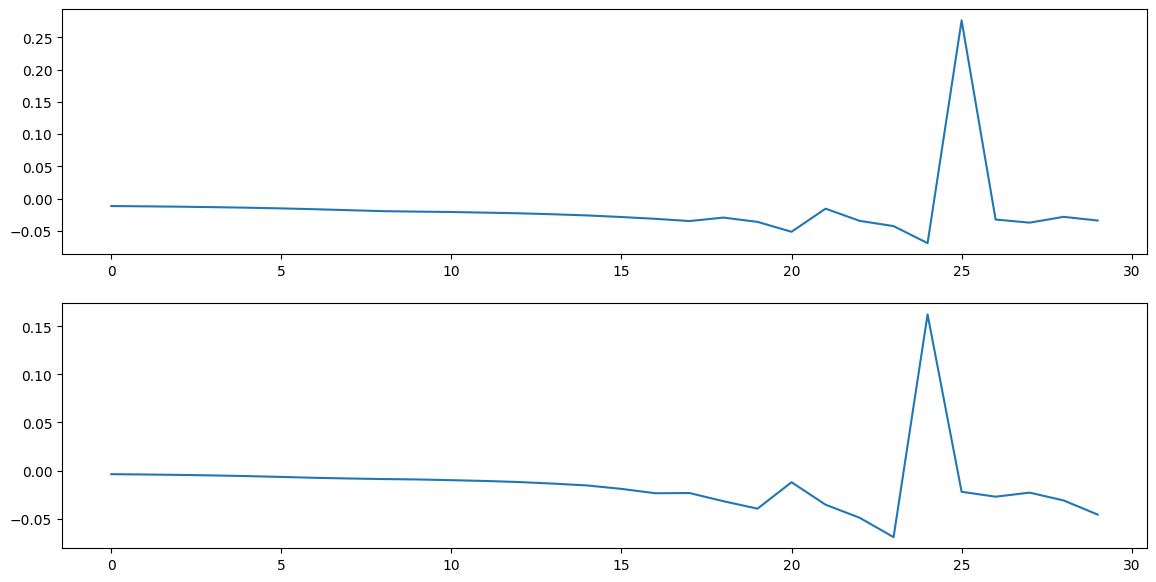

In [296]:
plt.figure(figsize=(14, 7))
plt.subplot(2, 1, 1)
plt.plot(train_history, label='Train')
plt.subplot(2, 1, 2)
plt.plot(val_history, label='Val')


In [297]:
epoch = tqdm(range(config.num_epochs), unit='epoch')

for e in epoch:
    model.train()
    loss = run_epoch(
        model, train_dataloader, optimizer, criterion)

    model.eval()

    train_history.append(eval_epoch(model, train_dataloader_infer))

    val_history.append(eval_epoch(model, val_dataloader, points=1000))
    

    print('##### TRAIN socre {:.4E} norm {:.4E} r: {:.4E} VALIDATION score {:.4E} norm {:.4E} r: {:.4E} #####'.format(*train_history[-1], *val_history[-1]))

    # epoch.set_description(
    #     '##### Train SCOREdata.shape[1] {:.4E}  Validation SCORE {:.4E}  #####'.format(train_score, validation_score))

  0%|          | 0/10 [00:00<?, ?epoch/s]

  0%|          | 0/1 [00:00<?, ?batch/s]

KeyboardInterrupt: 

In [298]:
print(model.linear1.weight, model.linear1.bias)

Parameter containing:
tensor([[-0.5600]], requires_grad=True) Parameter containing:
tensor([3.1691], requires_grad=True)


In [38]:
import seaborn as sns

def m1(inv, tgt):
    return (inv*tgt).mean()/(np.abs(np.diff(inv)).mean()+1e-5)

def grid_ab(dt, tgt, metric=m1):

    l = np.linspace(-1, -0.01, 101)

    l2 = np.linspace(-15, 15, 101)

    total_score = []

    for j in l2:

        score = []

        for i in l:
            
            inv = np.tanh(dt * i + j)
            
            # inv = inv - inv.mean()

            score.append(metric(inv, tgt))
        
        total_score.append(score)
        
    return np.array(total_score) 

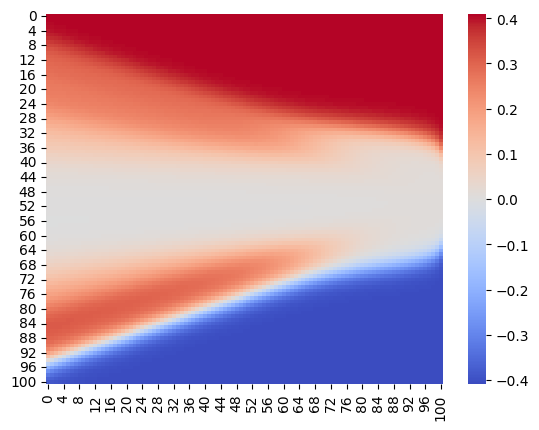

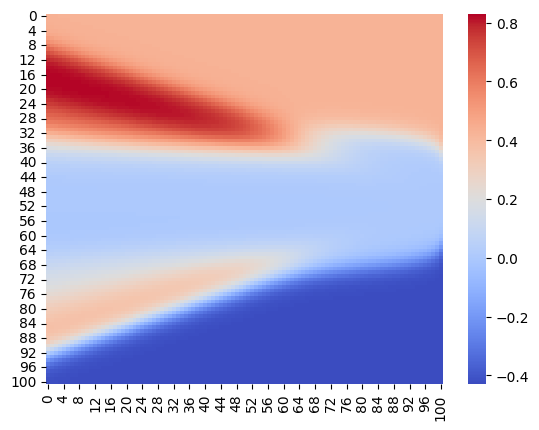

<Axes: >

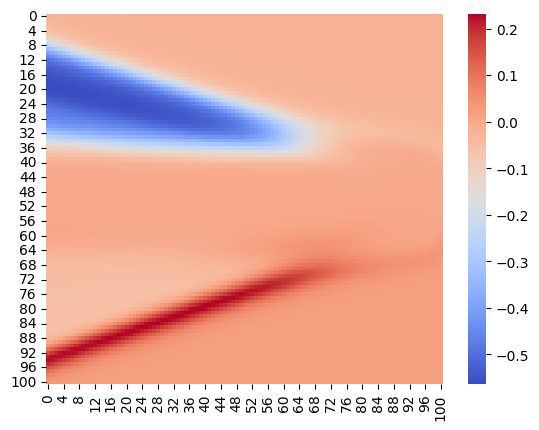

In [39]:

        
    
train_grid = grid_ab(train_data[:-1, 0], train_target[1:, 0])
test_grid = grid_ab(test_data[:-1, 0], test_target[1:, 0])

sns.heatmap(train_grid, cmap='coolwarm')
plt.show()
sns.heatmap(test_grid, cmap='coolwarm')
plt.show()
sns.heatmap(train_grid - test_grid, cmap='coolwarm')


/tmp/ipykernel_86983/1575722409.py:9: RuntimeWarning: invalid value encountered in log
  sns.heatmap(np.log(train_grid), cmap='coolwarm')


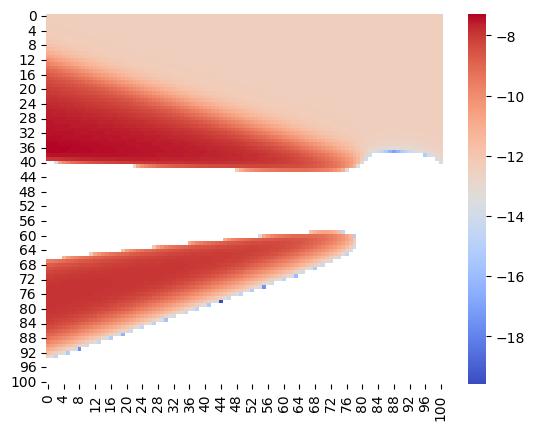

/tmp/ipykernel_86983/1575722409.py:11: RuntimeWarning: invalid value encountered in log
  sns.heatmap(np.log(test_grid), cmap='coolwarm')


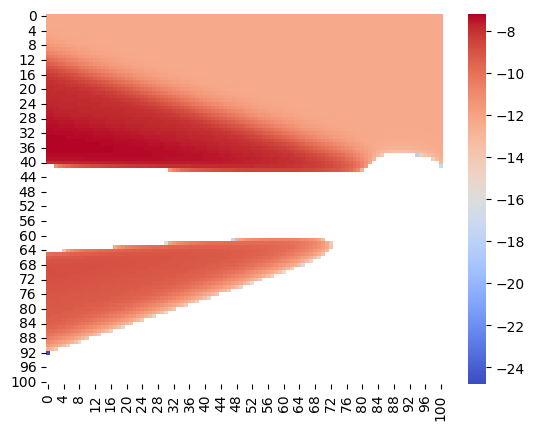

In [40]:

def m2(inv, tgt):
    return (inv*tgt).mean()-0.04*(np.abs(np.diff(inv)).mean())



train_grid = grid_ab(train_data[:-1, 0], train_target[1:, 0], metric=m2)
test_grid = grid_ab(test_data[:-1, 0], test_target[1:, 0], metric=m2)

sns.heatmap(np.log(train_grid), cmap='coolwarm')
plt.show()
sns.heatmap(np.log(test_grid), cmap='coolwarm')
plt.show()

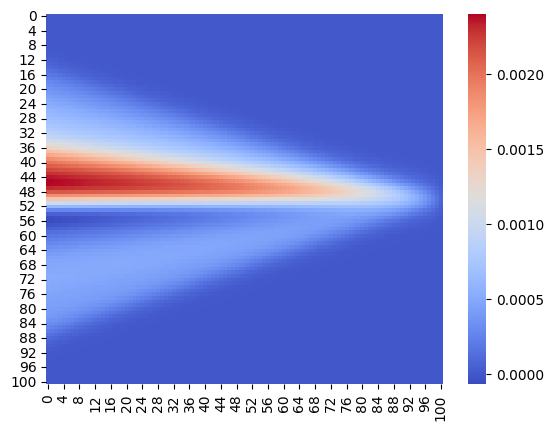

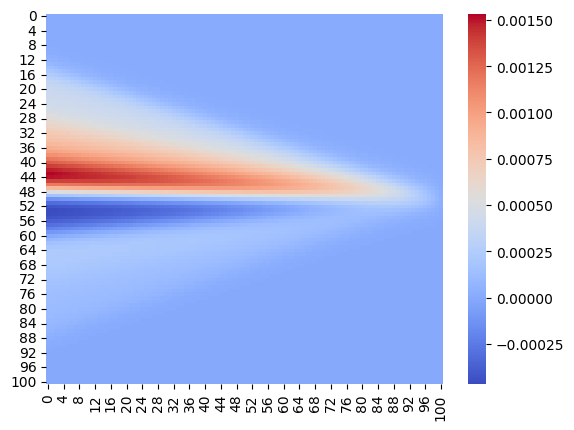

In [41]:

m3 = lambda inv, tgt: (inv*tgt).mean()

train_grid = grid_ab(train_data[:-1, 0], train_target[1:, 0], metric=m3)
test_grid = grid_ab(test_data[:-1, 0], test_target[1:, 0], metric=m3)

sns.heatmap(train_grid, cmap='coolwarm')
plt.show()
sns.heatmap(test_grid, cmap='coolwarm')
plt.show()


In [322]:
(1+np.max(total_score)/100)**(12*24*365)

np.float64(1.0508469522809805)

In [323]:
np.max(total_score)*(12*24*365)

np.float64(4.959647193713346)

In [320]:
np.max(total_score)

np.float64(0.00042755064005686256)

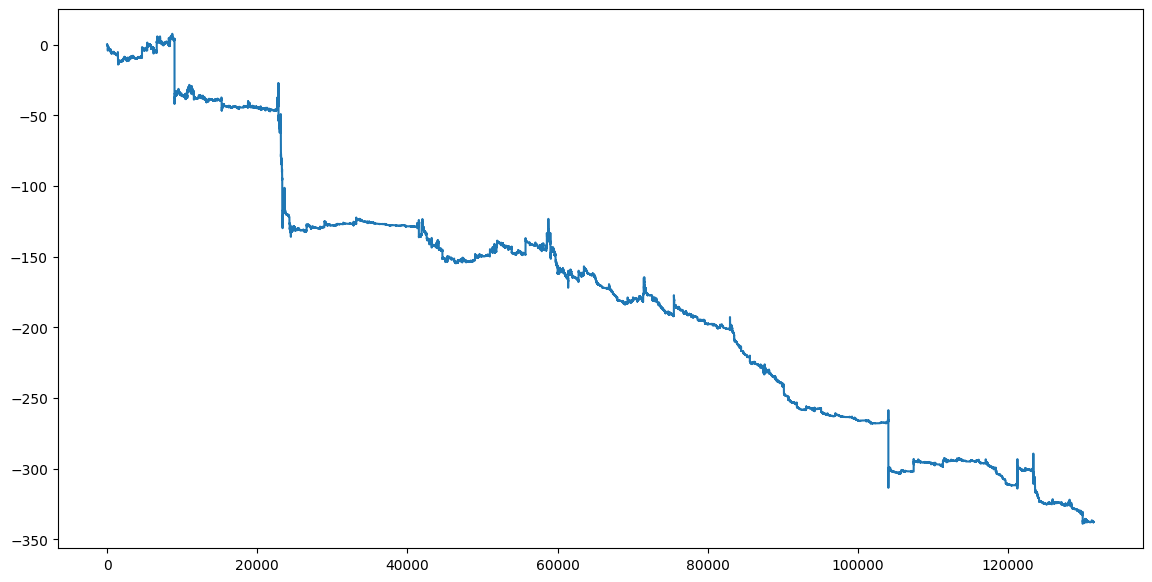

In [ ]:
rtest = (test_target[:-1] * test_data[1:])

plt.figure(figsize=(14, 7))
plt.plot(np.cumsum(rtest), label='True')

5.618632954070169e-18


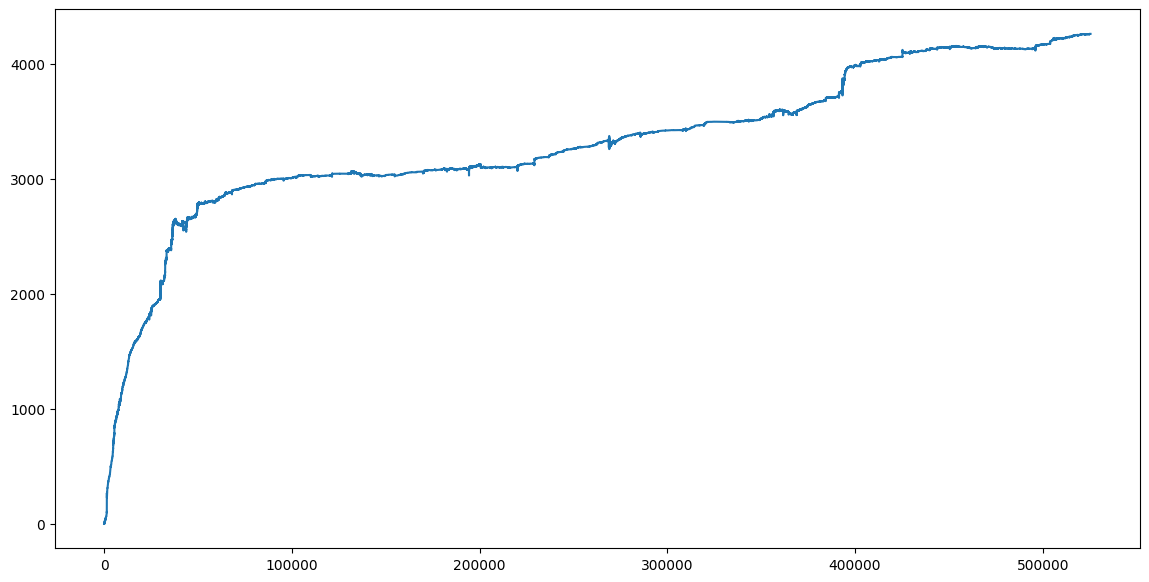

In [ ]:
r = (train_data[:-1] * -0.5)* train_target[1:]


print(train_target.mean())

rcm = np.cumsum(r)

plt.figure(figsize=(14, 7))
plt.plot(rcm)

##### LSTM 10 epoch TRAIN mse 9.9804E-01 mae 9.9112E-01 r: 0.0000E+00 VALIDATION mse 1.0025E+00 mae 9.9044E-01 r: 0.0000E+00 #####
##### CNN TRAIN mse 9.9705E-01 mae 9.9150E-01 r: 0.0000E+00 VALIDATION mse 1.0021E+00 mae 9.9299E-01 r: 0.0000E+00 #####

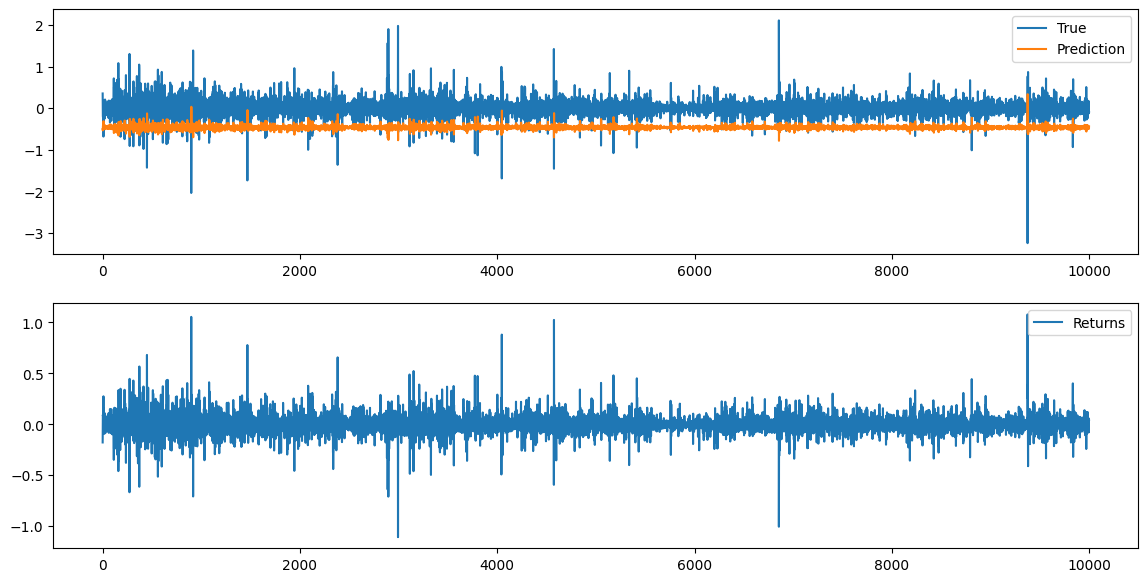

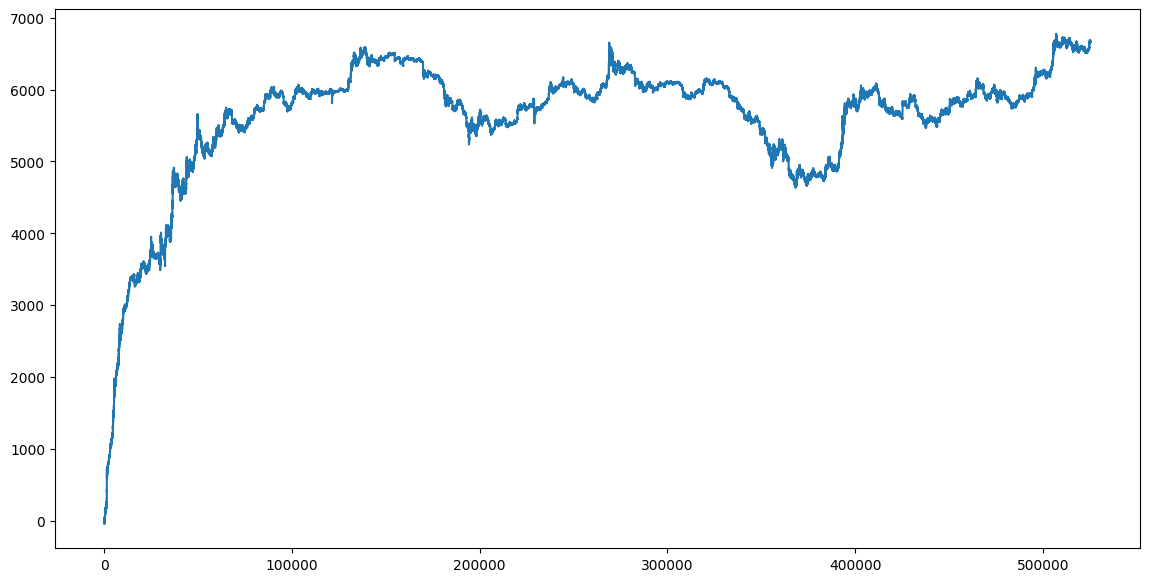

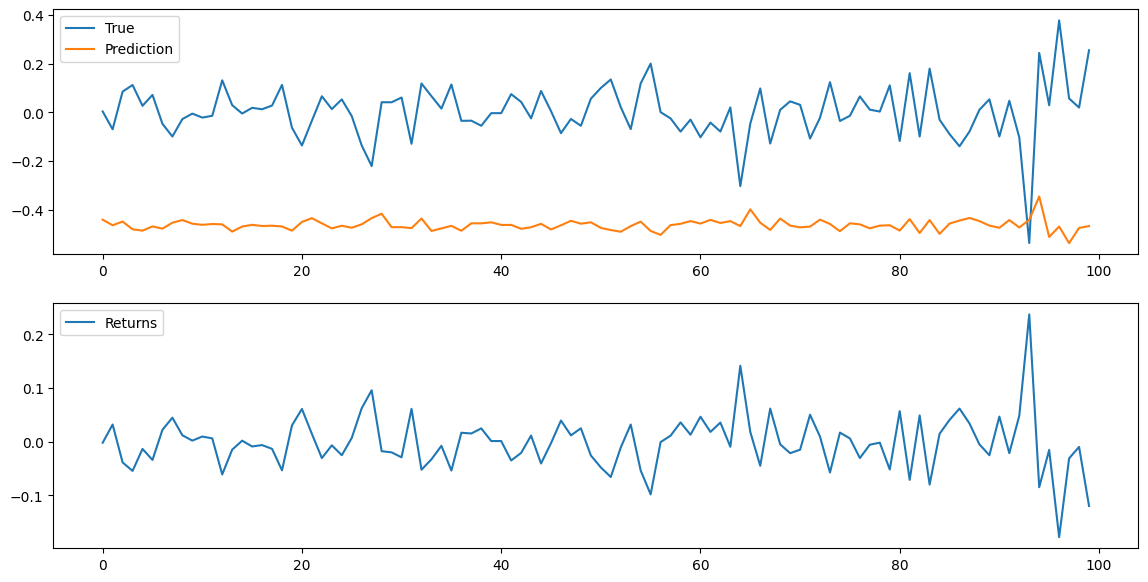

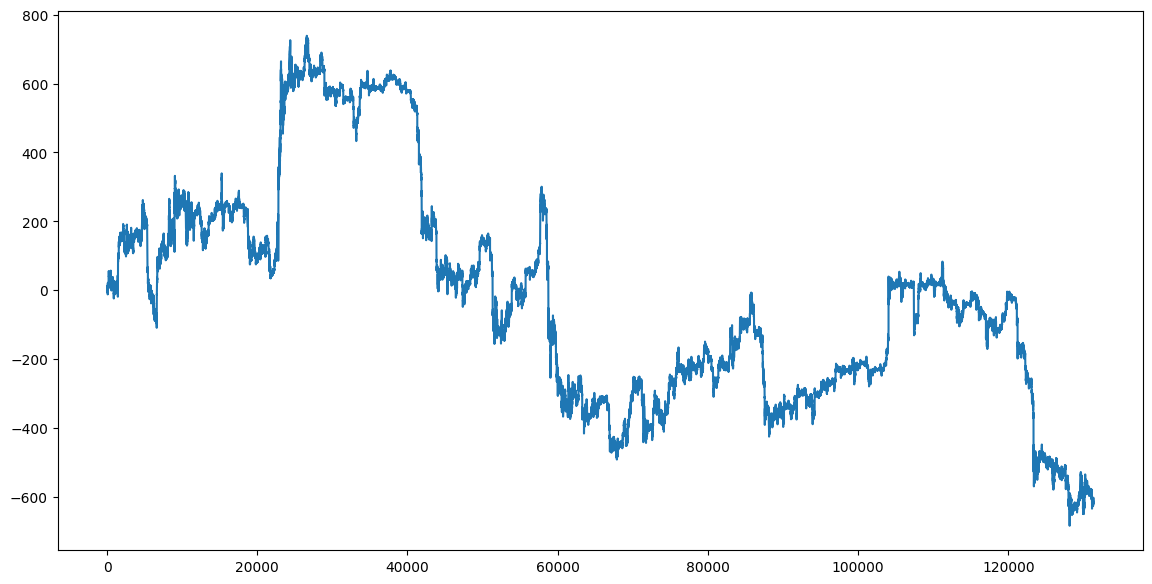

##### TRAIN mse 1.2673E-02 mae 5.0000E-02 r: 6.3365E-04 VALIDATION mse -4.7243E-03 mae 2.5029E-02 r: -1.1824E-04 #####


In [ ]:

print('##### TRAIN mse {:.4E} mae {:.4E} r: {:.4E} VALIDATION mse {:.4E} mae {:.4E} r: {:.4E} #####'.format(*eval_epoch(model, train_dataloader_infer, points=10000), *eval_epoch(model, val_dataloader, points=100)))
